In [2]:
import importlib
import aaro_draft
import pandas as pd
import matplotlib.pyplot as plt
import Conor
from IPython.display import Image, display
from joblib import Parallel, delayed
import Conor as c

# Reward 1

In [3]:
scalings = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]

configs = [
    c.ExpConfig(
        starting_state=4.0,
        action_lo=-5.0,
        action_hi=5.0,
        initial_q=100.0,
        rho=10.0,
        reward_step_fn=c.reward_quadratic_asymmetric,
        label=f"scaling={s}",
        scaling=s,
        alpha=0.5,
        nEps=2000,
        n_seeds=10,
    )
    for s in scalings
]

results = c.run_experiment(configs, n_jobs=-1)


--- Running: scaling=0.01 ---
    Done. Final mean VPI: -35.805

--- Running: scaling=0.05 ---
    Done. Final mean VPI: -38.843

--- Running: scaling=0.1 ---
    Done. Final mean VPI: -35.878

--- Running: scaling=0.5 ---
    Done. Final mean VPI: -29.566

--- Running: scaling=1 ---
    Done. Final mean VPI: -21.809

--- Running: scaling=5 ---
    Done. Final mean VPI: -3.468

--- Running: scaling=10 ---
    Done. Final mean VPI: -3.873

--- Running: scaling=50 ---
    Done. Final mean VPI: -59.325

--- Running: scaling=100 ---
    Done. Final mean VPI: -100.122

--- Running: scaling=500 ---
    Done. Final mean VPI: -149.411


In [4]:
import numpy as np
import pandas as pd

summary = []
for s in scalings:
    label = f"scaling={s}"
    vpi = results[label]["vpi"]
    arms = results[label]["arms"]

    summary.append({
        "scaling": s,
        "final_cum_reward": np.sum(vpi),
        "late_mean_reward": np.mean(vpi[-100:]),
        "final_arms": arms[-1],
        "mean_arms_last100": np.mean(arms[-100:])
    })

summary_df = pd.DataFrame(summary)
summary_df

,scaling,final_cum_reward,late_mean_reward,final_arms,mean_arms_last100
0,0.01,-71668.044440,-35.805084,218.2,217.975
1,0.05,-76955.920773,-38.842848,218.2,218.029
2,0.10,-70969.007794,-35.877744,217.3,217.300
3,0.50,-59810.016289,-29.565560,217.0,216.700
4,1.00,-45994.881937,-21.809435,218.8,218.626
5,5.00,-13944.170988,-3.467626,223.9,223.111
6,10.00,-14105.579770,-3.872912,220.0,217.420
7,50.00,-134754.693192,-59.324841,214.0,213.454
8,100.00,-217834.276931,-100.121537,212.2,210.856
9,500.00,-281145.700235,-149.411140,217.0,217.000


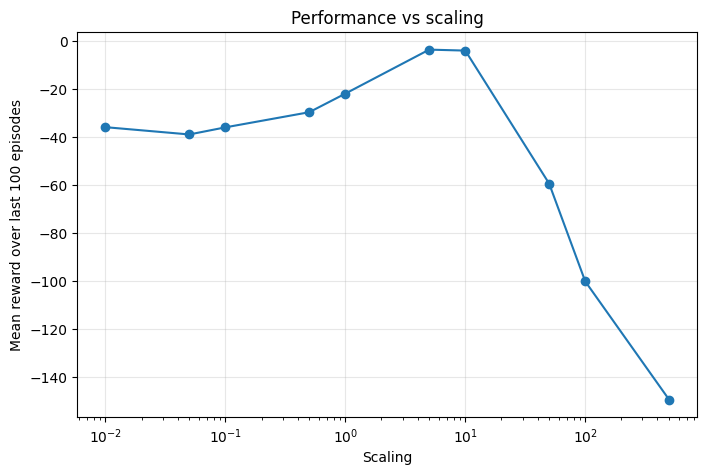

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["late_mean_reward"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

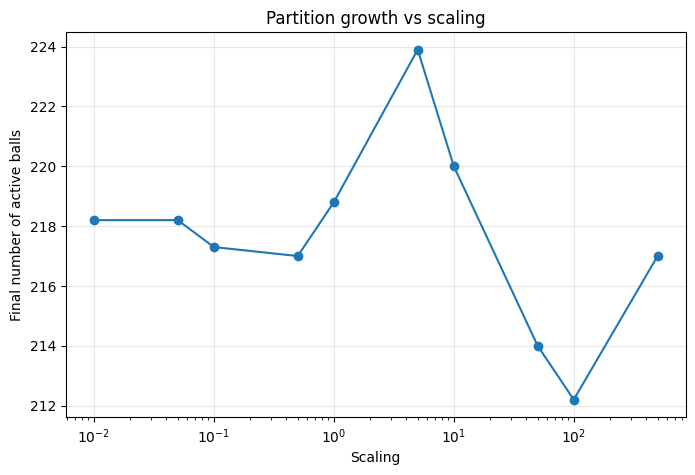

In [6]:
plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["final_arms"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Final number of active balls")
plt.title("Partition growth vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

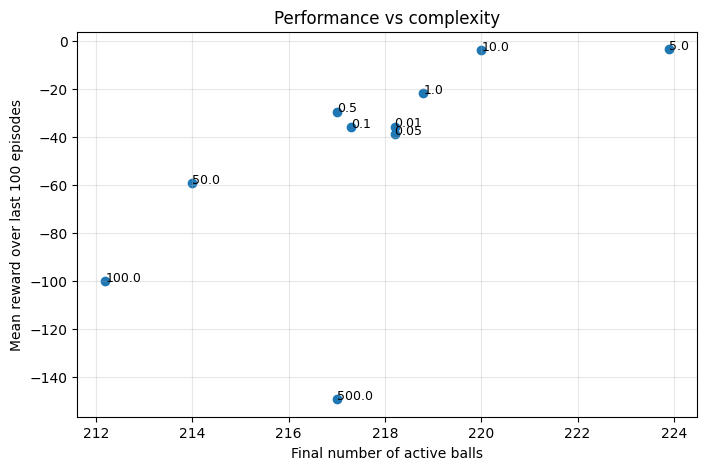

In [7]:
plt.figure(figsize=(8,5))
plt.scatter(summary_df["final_arms"], summary_df["late_mean_reward"])

for _, row in summary_df.iterrows():
    plt.annotate(
        str(row["scaling"]),
        (row["final_arms"], row["late_mean_reward"]),
        fontsize=9
    )

plt.xlabel("Final number of active balls")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs complexity")
plt.grid(True, alpha=0.3)
plt.show()

# Reward 2


In [8]:
scalings = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]

configs = [
    c.ExpConfig(
        starting_state=4.0,
        action_lo=-5.0,
        action_hi=5.0,
        initial_q=100.0,
        rho=10.0,
        reward_step_fn=c.reward_quadratic_shifted,
        label=f"scaling={s}",
        scaling=s,
        alpha=0.5,
        nEps=2000,
        n_seeds=10,
    )
    for s in scalings
]

results = c.run_experiment(configs, n_jobs=-1)


--- Running: scaling=0.01 ---
    Done. Final mean VPI: -7.937

--- Running: scaling=0.05 ---
    Done. Final mean VPI: -7.877

--- Running: scaling=0.1 ---
    Done. Final mean VPI: -7.015

--- Running: scaling=0.5 ---
    Done. Final mean VPI: -4.386

--- Running: scaling=1 ---
    Done. Final mean VPI: -2.239

--- Running: scaling=5 ---
    Done. Final mean VPI: -1.423

--- Running: scaling=10 ---
    Done. Final mean VPI: -3.696

--- Running: scaling=50 ---
    Done. Final mean VPI: -33.386

--- Running: scaling=100 ---
    Done. Final mean VPI: -52.620

--- Running: scaling=500 ---
    Done. Final mean VPI: -63.571


In [9]:
import numpy as np
import pandas as pd

summary = []
for s in scalings:
    label = f"scaling={s}"
    vpi = results[label]["vpi"]
    arms = results[label]["arms"]

    summary.append({
        "scaling": s,
        "final_cum_reward": np.sum(vpi),
        "late_mean_reward": np.mean(vpi[-100:]),
        "final_arms": arms[-1],
        "mean_arms_last100": np.mean(arms[-100:])
    })

summary_df = pd.DataFrame(summary)
summary_df

,scaling,final_cum_reward,late_mean_reward,final_arms,mean_arms_last100
0,0.01,-15497.015724,-7.936647,221.5,220.360
1,0.05,-15379.886123,-7.876763,221.5,220.363
2,0.10,-13720.140095,-7.014691,222.1,221.017
3,0.50,-9093.503504,-4.385997,221.8,220.579
4,1.00,-5722.894011,-2.239168,226.3,223.900
5,5.00,-4332.162816,-1.423281,214.3,212.899
6,10.00,-9734.676226,-3.695792,212.5,208.183
7,50.00,-74141.958504,-33.385890,208.9,208.297
8,100.00,-106286.517299,-52.619745,211.0,211.000
9,500.00,-120285.545952,-63.571139,217.0,217.000


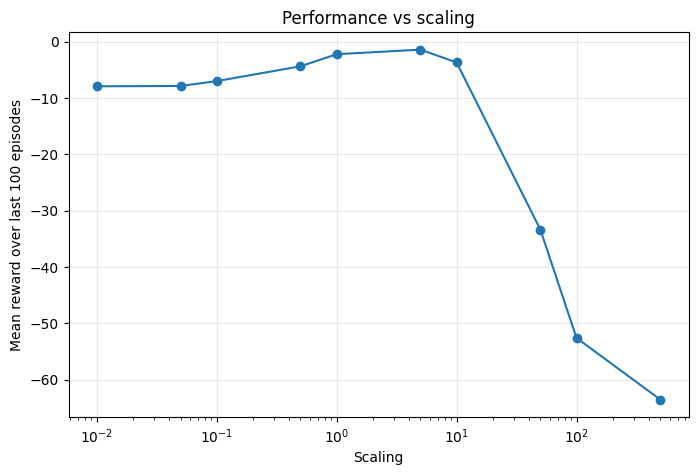

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["late_mean_reward"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

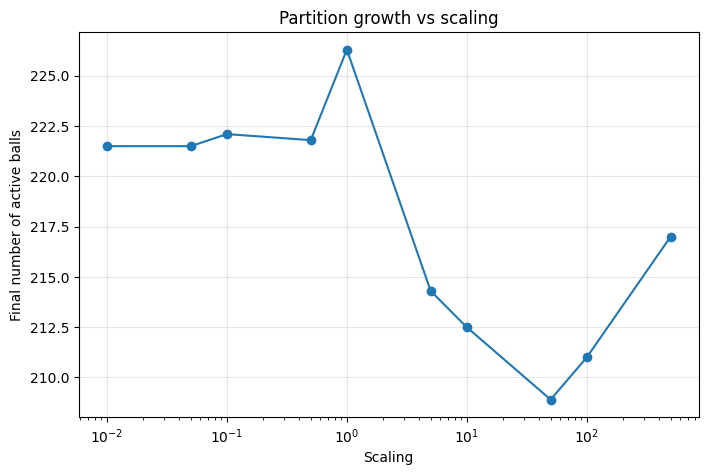

In [11]:
plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["final_arms"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Final number of active balls")
plt.title("Partition growth vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

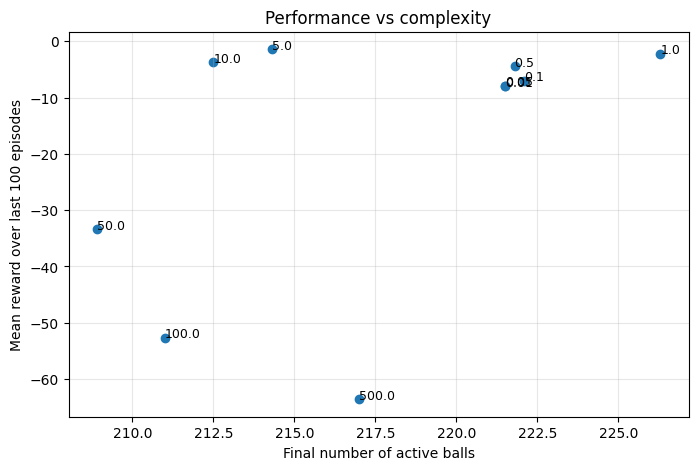

In [12]:
plt.figure(figsize=(8,5))
plt.scatter(summary_df["final_arms"], summary_df["late_mean_reward"])

for _, row in summary_df.iterrows():
    plt.annotate(
        str(row["scaling"]),
        (row["final_arms"], row["late_mean_reward"]),
        fontsize=9
    )

plt.xlabel("Final number of active balls")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs complexity")
plt.grid(True, alpha=0.3)
plt.show()

# Reward 3

In [13]:
scalings = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]

configs = [
    c.ExpConfig(
        starting_state=4.0,
        action_lo=-5.0,
        action_hi=5.0,
        initial_q=100.0,
        rho=10.0,
        reward_step_fn=c.reward_quartic,
        label=f"scaling={s}",
        scaling=s,
        alpha=0.5,
        nEps=2000,
        n_seeds=10,
    )
    for s in scalings
]

results = c.run_experiment(configs, n_jobs=-1)


--- Running: scaling=0.01 ---
    Done. Final mean VPI: -42.600

--- Running: scaling=0.05 ---
    Done. Final mean VPI: -42.517

--- Running: scaling=0.1 ---
    Done. Final mean VPI: -43.615

--- Running: scaling=0.5 ---
    Done. Final mean VPI: -34.510

--- Running: scaling=1 ---
    Done. Final mean VPI: -30.086

--- Running: scaling=5 ---
    Done. Final mean VPI: -8.986

--- Running: scaling=10 ---
    Done. Final mean VPI: -4.736

--- Running: scaling=50 ---
    Done. Final mean VPI: -30.766

--- Running: scaling=100 ---
    Done. Final mean VPI: -67.715

--- Running: scaling=500 ---
    Done. Final mean VPI: -211.778


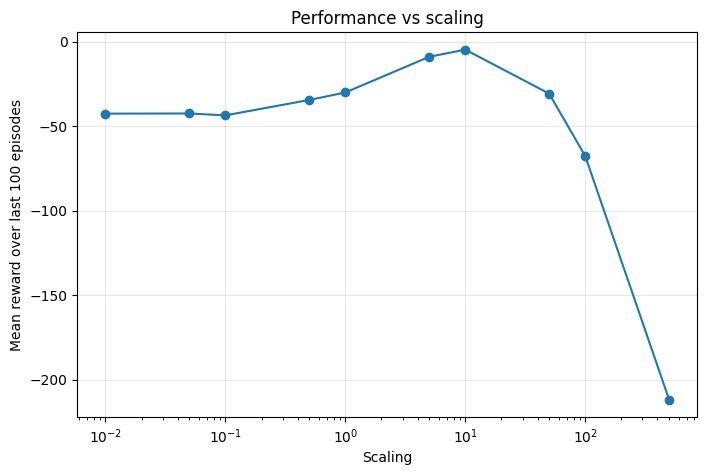

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["late_mean_reward"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
import numpy as np
import pandas as pd

summary = []
for s in scalings:
    label = f"scaling={s}"
    vpi = results[label]["vpi"]
    arms = results[label]["arms"]

    summary.append({
        "scaling": s,
        "final_cum_reward": np.sum(vpi),
        "late_mean_reward": np.mean(vpi[-100:]),
        "final_arms": arms[-1],
        "mean_arms_last100": np.mean(arms[-100:])
    })

summary_df = pd.DataFrame(summary)
summary_df

,scaling,final_cum_reward,late_mean_reward,final_arms,mean_arms_last100
0,0.01,-108511.990630,-42.600035,217.3,217.300
1,0.05,-108698.845990,-42.517499,218.5,218.212
2,0.10,-110535.099084,-43.615156,217.3,217.102
3,0.50,-93810.659040,-34.509973,218.2,218.200
4,1.00,-82906.637119,-30.085795,218.2,217.957
5,5.00,-36559.494730,-8.986047,219.7,218.749
6,10.00,-27773.948290,-4.736268,212.8,210.625
7,50.00,-88881.218885,-30.765687,211.3,210.817
8,100.00,-178464.137719,-67.714517,216.7,216.220
9,500.00,-406917.567735,-211.777810,217.0,217.000


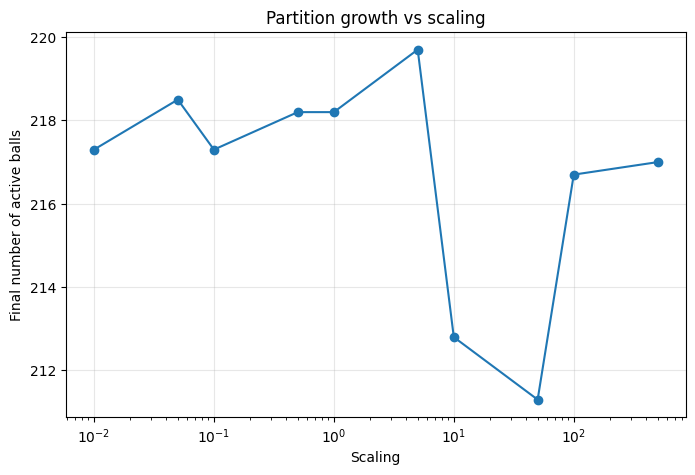

In [15]:
plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["final_arms"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Final number of active balls")
plt.title("Partition growth vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

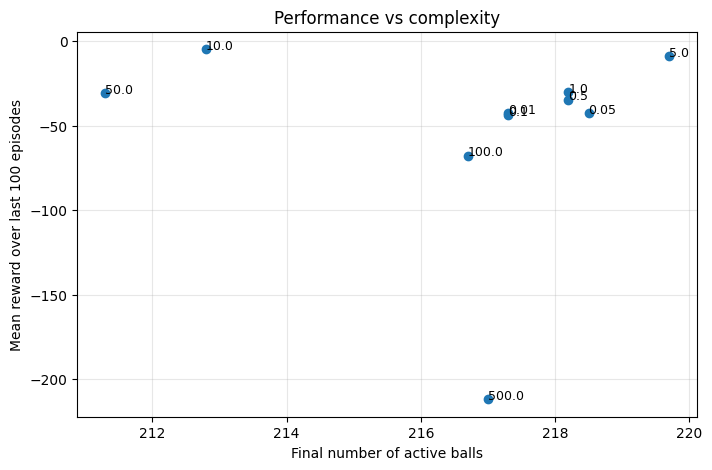

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(summary_df["final_arms"], summary_df["late_mean_reward"])

for _, row in summary_df.iterrows():
    plt.annotate(
        str(row["scaling"]),
        (row["final_arms"], row["late_mean_reward"]),
        fontsize=9
    )

plt.xlabel("Final number of active balls")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs complexity")
plt.grid(True, alpha=0.3)
plt.show()